# Lecture 09: Sample Means

---

## Outline

* [Central Limit Theorem](#Central-Limit-Theorem)
* [Distribution of the Sample Average](#Distribution-of-the-Sample-Average)
* [Center of the Distribution](#Center-of-the-Distribution)
* [Variability of the Sample Average](#Variability-of-the-Sample-Average)

---

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Redefine function from previous lecture
def standard_units(x):
    """Convert array x to standard units."""
    return (x - np.mean(x)) / np.std(x)

# To create normally distributed values
from scipy.stats import norm

In [2]:
# Some functions for plotting. You don't have to understand how any
# of the functions in this cell work, since they use things we 
# haven't learned about in Data 8.

 
def resize_window(lim=3.5):
    plots.xlim(-lim, lim)
    plots.ylim(-lim, lim)
    
def draw_line(slope=0, intercept=0, x=make_array(-4, 4), color='#1e90ff'):
    y = x*slope + intercept
    plots.plot(x, y, color=color, lw=3)
    
def draw_vertical_line(x_position, color='black'):
    x = make_array(x_position, x_position)
    y = make_array(-4, 4)
    plots.plot(x, y, color=color, lw=3)
    
def make_correlated_data(r):
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    return x, y

def r_scatter(r):
    """Generate a scatter plot with a correlation approximately r"""
    plots.figure(figsize=(5,5))
    x, y = make_correlated_data(r)
    plots.scatter(x, y, color='darkblue', s=20)
    plots.xlim(-4, 4)
    plots.ylim(-4, 4)
    
def r_table(r):
    """
    Generate a table of 1000 data points with a correlation approximately r
    """
    np.random.seed(8)
    x, y = make_correlated_data(r)
    return Table().with_columns('x', x, 'y', y)

def standard_units(arr):
    """ Converts an array to standard units """
    return (arr - np.average(arr))/np.std(arr)

def correlation(t, x, y):
    """ Computes correlation: t is a table, and x and y are column names """
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regressions estimates at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b


Definition. The average or mean of a collection of numbers is the sum of all the elements of the collection, divided by the number of elements in the collection.

The methods np.average and np.mean return the mean of an array.

In [3]:
not_symmetric = make_array(2, 3, 3, 9)

In [4]:
np.average(not_symmetric)

4.25

In [5]:
np.mean(not_symmetric)

4.25

In [6]:
zero_one = make_array(1, 1, 1, 0)
sum(zero_one)

3

In [ ]:
np.mean(zero_one)

In [7]:
np.mean(make_array(True, True, True, False))

0.75

In [8]:
not_symmetric

array([2, 3, 3, 9])

In [9]:
same_distribution = make_array(2, 2, 3, 3, 3, 3, 9, 9)
np.mean(same_distribution)

4.25

In [10]:
symmetric = make_array(2, 3, 3, 4)

In [11]:
np.mean(symmetric)

3.0

In [12]:
percentile(50, symmetric)

3

In [13]:
sf2015 = Table.read_table('san_francisco_2015.csv').where('Salaries', are.above(10000))

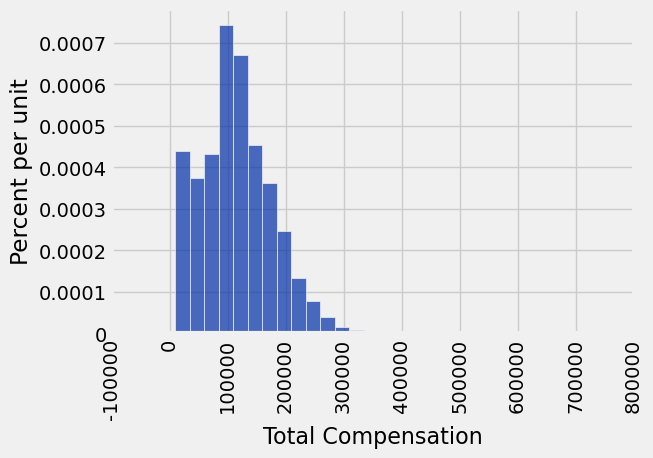

In [14]:
sf2015.select('Total Compensation').hist(bins = np.arange(10000, 700000, 25000))

In [15]:
compensation = sf2015.column('Total Compensation')
percentile(50, compensation)

110305.78999999999

In [16]:
np.mean(compensation)

114725.98411824222

---

## Central Limit Theorem

---

### Sample Averages

* The Central Limit Theorem describes how the normal distribution (a bell-shaped curve) is connected to random sample averages.
* We care about sample averages because they estimate population averages.

---

### Central Limit Theorem

> The probability distribution of the sum or average of a large random sample drawn with replacement will be roughly normal, regardless of the distribution of the population from which the sample is drawn.

---

### Demo: Central Limit Theorem

* Load the November 2023 flight delay data in `delay.csv` sourced from the [Bureau of Transportation Statistic's Reporting Carrier On-Time Performance Data](https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr). The variable `ARR_DELAY` contains the difference in minutes between scheduled and actual arrival time at the destination airport `DEST`. Early arrivals show negative numbers, and the airline code is expressed in the variable `OP_CARRIER`. 
* Demonstrate the Central Limit Theorem by showing how the distribution of sample means changes as the sample size increases.

In [17]:
sfo = (Table.read_table('delays.csv')
            .where('ORIGIN', 'SFO'))
nan_filter = np.invert(np.isnan(sfo.column('ARR_DELAY')))
sfo = sfo.where(nan_filter)
sfo

FL_DATE,OP_CARRIER,ORIGIN,DEST,ARR_DELAY
6/1/25 12:00 AM,AA,SFO,CLT,-3
6/1/25 12:00 AM,AA,SFO,CLT,-2
6/1/25 12:00 AM,AA,SFO,CLT,3
6/1/25 12:00 AM,AA,SFO,CLT,18
6/1/25 12:00 AM,AA,SFO,CLT,77
6/1/25 12:00 AM,AA,SFO,DFW,-36
6/1/25 12:00 AM,AA,SFO,DFW,-12
6/1/25 12:00 AM,AA,SFO,DFW,-3
6/1/25 12:00 AM,AA,SFO,DFW,-1
6/1/25 12:00 AM,AA,SFO,DFW,1


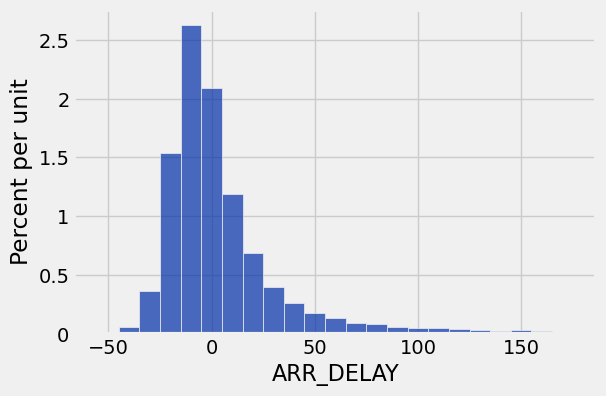

In [18]:
sfo.hist('ARR_DELAY', bins=np.arange(-55, 180, 10))

In [19]:
delays = sfo.column('ARR_DELAY')
delay_mean = np.mean(delays)
delay_sd = np.std(delays)
(print(f'The average flight delay was {delay_mean: .2f} \
mins with a standard deviation of {delay_sd:.2f} mins.'))

The average flight delay was  6.94 mins with a standard deviation of 45.95 mins.


In [20]:
def one_sample_mean(sample_size):
    """ Takes a sample from the population of flights and computes its mean"""
    sampled_flights = sfo.sample(sample_size)
    sampled_delays = sampled_flights.column('ARR_DELAY')
    mean_delay = np.mean(sampled_delays)
    return mean_delay

In [21]:
one_sample_mean(100)

8.5500000000000007

In [22]:
def ten_thousand_sample_means(sample_size):
    means = make_array()
    for i in np.arange(10_000):
        one_mean = one_sample_mean(sample_size)
        means = np.append(means, one_mean)
    return means

Population Average: 6.93856982883


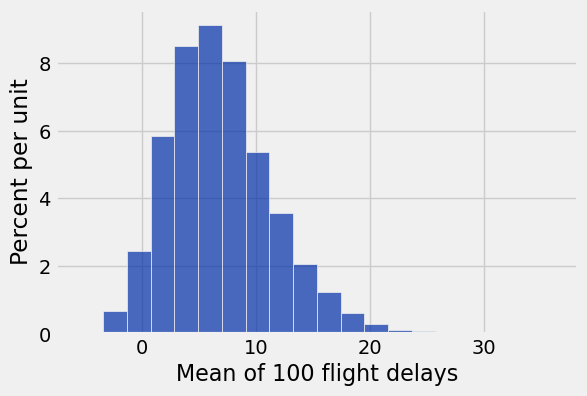

In [23]:
sample_means_100 = ten_thousand_sample_means(100)
Table().with_column('Mean of 100 flight delays', sample_means_100).hist(bins=20)
print('Population Average:', delay_mean)

Population Average: 6.93856982883


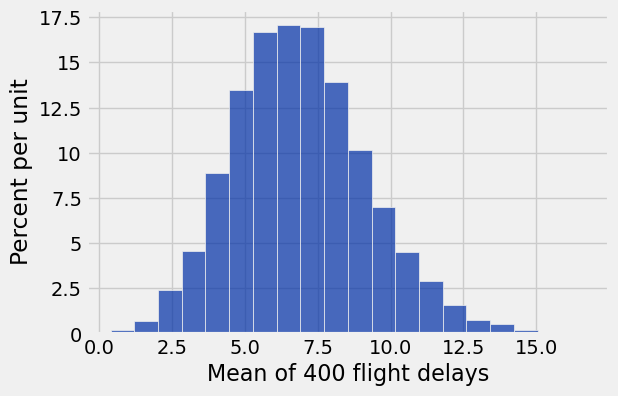

In [31]:
sample_means_400 = ten_thousand_sample_means(400)
Table().with_column('Mean of 400 flight delays', sample_means_400).hist(bins=20)
print('Population Average:', delay_mean)

Population Average: 6.93856982883


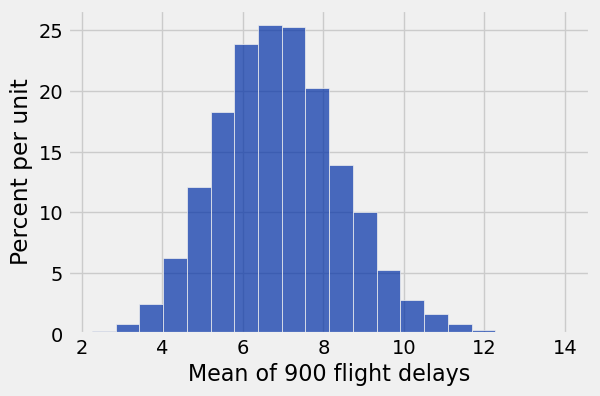

In [32]:
sample_means_900 = ten_thousand_sample_means(900)
Table().with_column('Mean of 900 flight delays', sample_means_900).hist(bins=20)
print('Population Average:', delay_mean)

---

## Proportion of Purple Flowers
Recall Mendel’s probability model for the colors of the flowers of a species of pea plant. The model says that the flower colors of the plants are like draws made at random with replacement from {Purple, Purple, Purple, White}.

In a large sample of plants, about what proportion will have purple flowers? We would expect the answer to be about 0.75, the proportion purple in the model. And, because proportions are means, the Central Limit Theorem says that the distribution of the sample proportion of purple plants is roughly normal.

We can confirm this by simulation. Let’s simulate the proportion of purple-flowered plants in a sample of 200 plants.

In [25]:
colors = make_array('Purple', 'Purple', 'Purple', 'White')

model = Table().with_column('Color', colors)

model

Color
Purple
Purple
Purple
White


In [26]:
props = make_array()

num_plants = 200
repetitions = 10000

for i in np.arange(repetitions):
    sample = model.sample(num_plants)
    new_prop = np.count_nonzero(sample.column('Color') == 'Purple')/num_plants
    props = np.append(props, new_prop)
    
results = Table().with_column('Sample Proportion: 200', props)

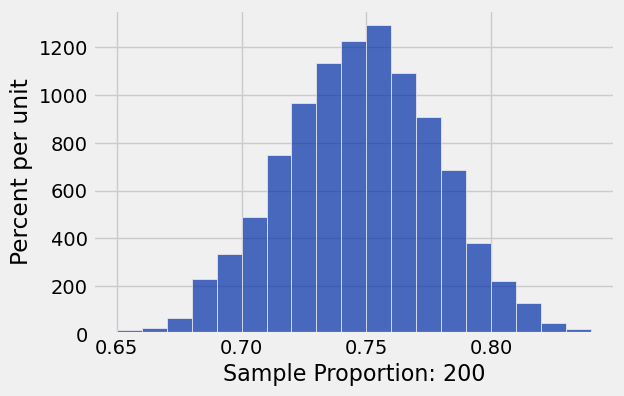

In [27]:
results.hist(bins=np.arange(0.65, 0.85, 0.01))

In [28]:
props2 = make_array()

num_plants = 800

for i in np.arange(repetitions):
    sample = model.sample(num_plants)
    new_prop = np.count_nonzero(sample.column('Color') == 'Purple')/num_plants
    props2 = np.append(props2, new_prop)
    
results = results.with_column('Sample Proportion: 800', props2)

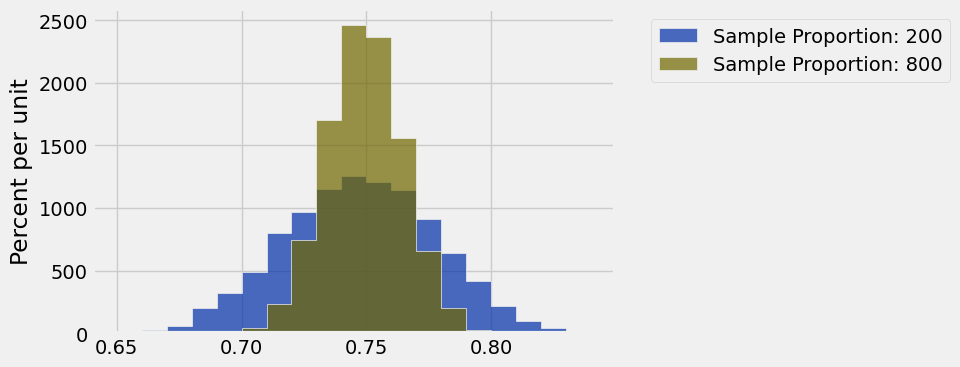

In [25]:
results.hist(bins=np.arange(0.65, 0.85, 0.01))

## Distribution of the Sample Average

---

### Why is There a Distribution?

* You have only one random sample, and it has only one average. 
* But the sample could have come out differently.
* And then the sample average might have been different.
* So there are many possible sample averages.


In [29]:
(print(f"There are {sfo.num_rows ** 400:,} possible \
samples of size 400 from this data set."))

There are 6,191,527,792,363,670,528,914,572,145,075,580,039,538,961,327,662,909,318,149,828,549,139,321,406,471,573,532,389,893,268,389,275,438,483,568,949,586,468,892,230,378,859,456,422,174,446,158,661,732,087,071,692,251,037,470,408,626,425,476,724,049,767,352,161,041,925,440,377,018,687,024,875,029,615,763,099,064,937,243,296,222,715,508,566,176,607,609,432,281,793,943,995,516,707,366,786,403,355,045,167,178,157,955,305,866,098,826,962,785,676,011,037,610,487,464,892,326,443,182,891,226,067,029,624,360,515,428,009,131,359,593,531,078,146,764,172,172,660,598,441,731,952,058,022,789,486,226,447,337,876,297,657,356,502,155,766,931,307,420,479,727,719,772,253,531,839,160,946,675,529,547,706,146,773,535,194,475,448,239,288,005,249,731,170,813,893,255,333,719,728,690,190,430,109,260,929,387,904,259,582,278,272,951,549,878,925,509,423,751,820,365,262,132,395,407,979,387,898,491,140,548,222,056,097,598,370,714,978,699,181,031,490,774,598,835,637,996,189,921,388,683,294,758,363,992,270,587,

---

### Distribution of the Sample Average 

* Imagine all possible random samples of the same size as yours. There are lots of them.
* Each of these samples has an average.
* The distribution of the sample average is the distribution of the averages of all the possible samples.

---

### Demo: Distribution of the Sample Average

Compare the distribution of sample averages for a few different sample sizes.

In [33]:
means_tbl = Table().with_columns(
    '400', sample_means_400,
    '900', sample_means_900)

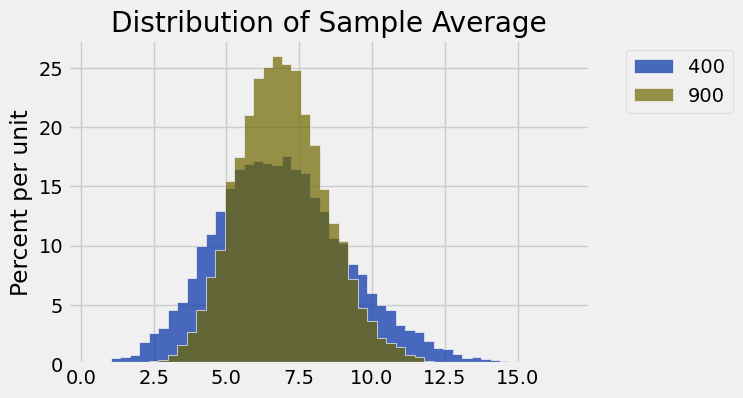

In [34]:
means_tbl.hist(bins = 50)
plt.title('Distribution of Sample Average')
plt.show()

---

### Specifying the Distribution

* Suppose the random sample is large.
    * We have seen that the distribution of the sample average is roughly bell shaped.
* Important questions remain:
    * Where is the center of that bell curve?
    * How wide is that bell curve?

---

## Center of the Distribution

---

###  The Population Average

The distribution of the sample average is roughly a bell curve centered at the population average.

---

## Variability of the Sample Average

---

### Why Is This Important?

* Along with the center, the spread helps identify exactly which normal curve is the distribution of the sample average.
* The variability of the sample average helps us measure how accurate the sample average is as an estimate of the population average.
* If we want a specified level of accuracy, understanding the variability of the sample average helps us work out how large our sample has to be.

---

### Two Histogram

<img src="./dist_sample_ave_update.png" width = 50%>

* The green histogram shows the distribution of 10,000 values, each of which is an average of 900 randomly sampled flight delays.
* The blue histogram shows the distribution of 10,000 values, each of which is an average of 400 randomly sampled flight delays.
* Both are roughly bell shaped.
* The larger the sample size, the narrower the bell.

---

### Demo: The Influence of Sample Size

Re-display the population mean and standard deviation.

In [35]:
(print(f'The average flight delay was {delay_mean: .2f} \
mins with a standard deviation of {delay_sd:.2f} mins.'))

The average flight delay was  6.94 mins with a standard deviation of 45.95 mins.


* Notice how the sample size impacts the distribution of sample averages.
* Additionally, notice how the ratio of the population SD to the sample SD is approximately equal to the square root of the sample size.

In [39]:
def plot_and_summarize_sample_means(sample_size):
    """Empirical distribution of random sample means"""
    sample_means = ten_thousand_sample_means(sample_size)
    sample_means_tbl = Table().with_column('Sample Means', sample_means)
    sample_mean = np.mean(sample_means)
    sample_sd = np.std(sample_means)
    
    # Print some information about the distribution of the sample means
    print("Sample size: ", sample_size)
    print("Population mean:", delay_mean)
    print("Average of sample means: ", sample_mean)
    print("Population SD:", delay_sd)
    print("SD of sample means:", sample_sd)
    print("Ratio of population SD to sample SD:", delay_sd / sample_sd)
    print("Square Root of the sample size:", np.sqrt(sample_size))

    # Plot a histogram of the sample means
    sample_means_tbl.hist(bins=20)
    plt.xlabel('Sample Means')
    plt.title('Sample Size ' + str(sample_size))

    # Overlay a curve representing the normal distribution
    from scipy.stats import norm
    x = np.linspace(np.min(sample_means), np.max(sample_means), 100)
    y = norm.pdf(x, delay_mean, delay_sd/np.sqrt(sample_size))
    plt.plot(x, y, linestyle='--', lw=5, label='Normal Distribution')

    # Add a vertical dashed line showing the mean delay
    plt.axvline(x=delay_mean, color='black', linestyle='--', lw=2, label='Population Mean')
    plt.legend()

Sample size:  100
Population mean: 6.93856982883
Average of sample means:  6.899372
Population SD: 45.9522513945
SD of sample means: 4.56908233518
Ratio of population SD to sample SD: 10.0572167502
Square Root of the sample size: 10.0


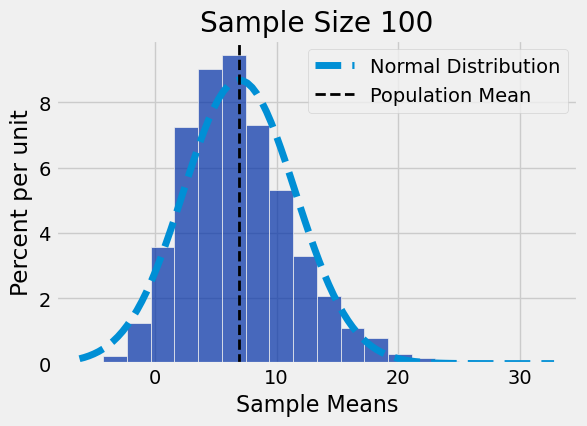

In [40]:
plot_and_summarize_sample_means(100)

Sample size:  400
Population mean: 6.93856982883
Average of sample means:  6.94515325
Population SD: 45.9522513945
SD of sample means: 2.3131623702
Ratio of population SD to sample SD: 19.8655537487
Square Root of the sample size: 20.0


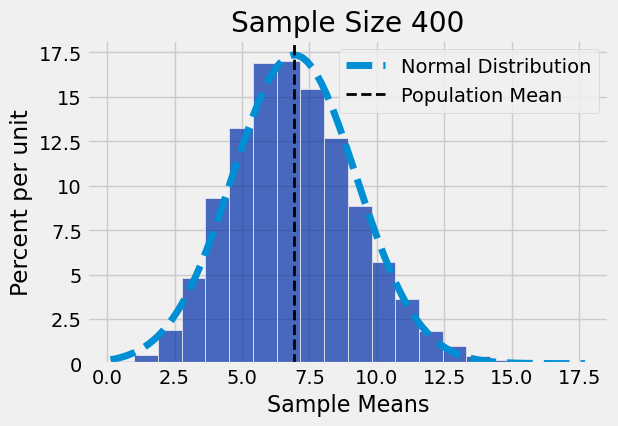

In [32]:
plot_and_summarize_sample_means(400)

Sample size:  625
Population mean: 6.93856982883
Average of sample means:  6.938016
Population SD: 45.9522513945
SD of sample means: 1.83838862701
Ratio of population SD to sample SD: 24.9959397699
Square Root of the sample size: 25.0


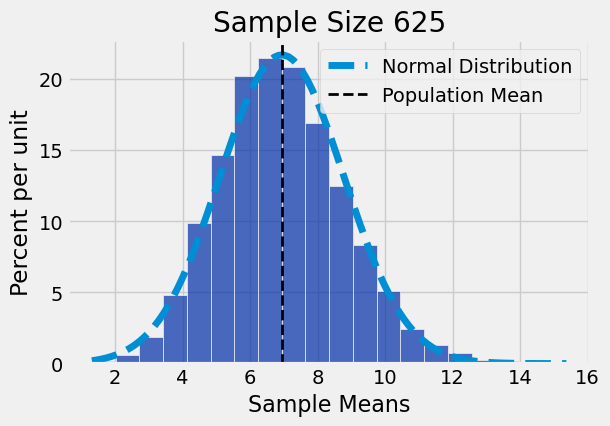

In [33]:
plot_and_summarize_sample_means(625)

---

### Probability of Sample Average

* The distribution of all possible sample averages of a given size is called the distribution of the sample average.
* We approximate the distribution of sample averages by an empirical distribution.

---

### The Central Limit Theorem

* If 
    * the sample is large and 
    * drawn at random with replacement, 
* Then, regardless of the distribution of the population, the probability distribution of the sample average:
    * is roughly normal
    * mean = population mean
    * SD = (population SD) / the square root of the sample size
    
_Note: For this [theory](https://en.wikipedia.org/wiki/Central_limit_theorem), the results are more reliable when the data has been standardized._

---

# Sample Size

---

## Outline

* [Confidence Intervals](#Confidence-Intervals)
* [Sample Proportions](#Sample-Proportions)

---

## Confidence Intervals

---

### Graph of the Distribution

<img src="./approx_dist_sample_ave.png" width=50%>

---

### The Key to 95% Confidence 

<img src="./95_confidence.png" width=80%>

* For about 95% of all samples, the sample average and population average are within 2 SDs of each other.
* SD = SD of sample average = $(\text{population SD}) / \sqrt{\text{sample size}}$


---

### Constructing the Interval

For about 95% of all samples,

* If you stand at the population average and look two SDs on both sides, you will find the sample average.
* Distance is symmetric.
* So if you stand at the sample average and look two SDs on both sides, you will capture the population average.


---

### The Interval

<img src="./the_interval_mean.png" width=80%>

---

### Width of the Interval

Total width of a 95% confidence interval for the population average

* $=  4 * \text{SD of the sample average}$
* $=  4 * (\text{population SD}) / \sqrt{\text{sample size}}$
* The $\text{population SD}$ is unknown in practice...


---

## Sample Proportions

---

### Proportions are Averages

* Data: 1 1 1 1 0 0 0 0 0 0 (10 entries)
    * Sum  =  4  (number of 1's)
    * Average  =  4/10  =  0.4 (proportion of 1's)
* If the population consists of 1's and 0's (yes/no answers to a question), then:
    * the population average is the proportion of 1's in the population
    * the sample average is the proportion of 1's in the sample


In [41]:
number_of_ones = 4
zero_one_population = np.append(np.ones(number_of_ones), 
                                np.zeros(10 - number_of_ones))
zero_one_population

array([ 1.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.])

In [42]:
np.mean(zero_one_population)

0.40000000000000002

---

### Confidence Interval

<img src="./the_interval_prop.png" width=80%>

---

### Controlling the Width

* The width of an approximate 95% confidence interval for a population proportion is given by the following formula:

$$\text{width of 95\% confidence interval} = 4 * \left(\frac{\text{SD of 0/1 population}}{\sqrt{\text{sample size}}}\right)$$

* The narrower the interval, the more precise your estimate.
* Suppose you want the total width of the interval to be no more than 1%. How should you choose the sample size?


---

### The Sample Size for a Given Width

* From Formula: $0.01  =  4 * \left(\frac{\text{SD of 0/1 population}}{\sqrt{\text{sample size}}}\right)$
    * Left side: 1%, the max total width that you'll accept
    * Right side: formula for the total width
* Re-arrange: $\sqrt{\text{sample size}} =  4 * \left(\frac{\text{SD of 0/1 population}}{0.01}\right)$
* Result: $\text{sample size} = \left(4 * \left(\frac{\text{SD of 0/1 population}}{0.01}\right)\right)^2$

---

### Demo: SD of 0/1 Population

* Calculate the SD of the 0/1 population
* Make a graph with proportion of ones on the x axis and SD on the y axis.

In [43]:
zero_one_population

array([ 1.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.])

In [44]:
np.std(zero_one_population)

0.48989794855663565

In [45]:
def sd_of_zero_one_population(number_of_ones):
    """
    SD of a population with num_ones ones 
    and (10 - num_ones) zeros
    """
    zero_one_population = np.append(np.ones(number_of_ones),
                                    np.zeros(10 - number_of_ones))
    return np.std(zero_one_population)

In [46]:
possible_ones = np.arange(11)
zero_one_pop = Table().with_columns(
    'Number of ones', possible_ones,
    'Proportion of ones', possible_ones / 10
)

In [47]:
sds = zero_one_pop.apply(sd_of_zero_one_population, 'Number of ones')
zero_one_pop = zero_one_pop.with_column('SD', sds)

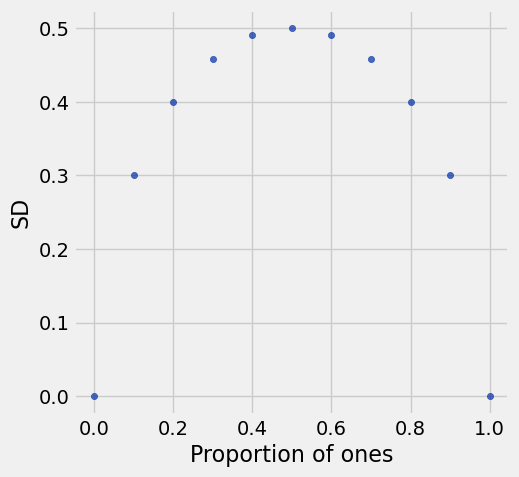

In [48]:
zero_one_pop.scatter('Proportion of ones', 'SD')